In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from xgboost import XGBClassifier
import shap


In [ ]:
df = pd.read_csv('/content/loan.csv', low_memory= False)
print (df.shape)
print (df.head())


(21071, 151)
         id  member_id  loan_amnt  funded_amnt  funded_amnt_inv        term  \
0  68407277        NaN     3600.0       3600.0           3600.0   36 months   
1  68355089        NaN    24700.0      24700.0          24700.0   36 months   
2  68341763        NaN    20000.0      20000.0          20000.0   60 months   
3  66310712        NaN    35000.0      35000.0          35000.0   60 months   
4  68476807        NaN    10400.0      10400.0          10400.0   60 months   

   int_rate  installment grade sub_grade  ... hardship_payoff_balance_amount  \
0     13.99       123.03     C        C4  ...                            NaN   
1     11.99       820.28     C        C1  ...                            NaN   
2     10.78       432.66     B        B4  ...                            NaN   
3     14.85       829.90     C        C5  ...                            NaN   
4     22.45       289.91     F        F1  ...                            NaN   

  hardship_last_payment_amount 

In [ ]:
for col in df.select_dtypes(include ='number').columns:
  df[col] = df[col].fillna(df[col].median())
for col in df.select_dtypes(include='object').columns:
  df[col] = df[col].fillna('Unknown')

In [ ]:
threshold = len(df)* 0.4
df = df.dropna(thresh=threshold, axis=1)
print (df.shape)

(21071, 137)


In [ ]:
df['default'] = df['loan_status'].apply(
    lambda x: 1 if x in ['Charged Off', 'Default', ] else 0
)
print(df['default'].value_counts())


default
0    17300
1     3771
Name: count, dtype: int64


/tmp/ipykernel_790/829741939.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['default'] = df['loan_status'].apply(


In [ ]:
df_original = df.copy()

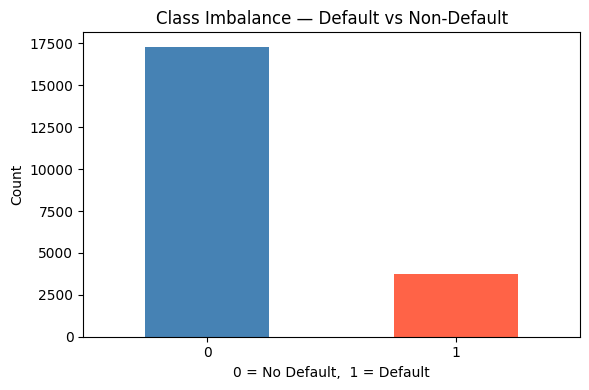

In [ ]:
plt.figure(figsize=(6,4))
df_original['default'].value_counts().plot(kind='bar', color=['steelblue','tomato'])
plt.title('Class Imbalance — Default vs Non-Default')
plt.xlabel('0 = No Default,  1 = Default')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

/tmp/ipykernel_790/1393353823.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='grade', y='default', data=df_plot,


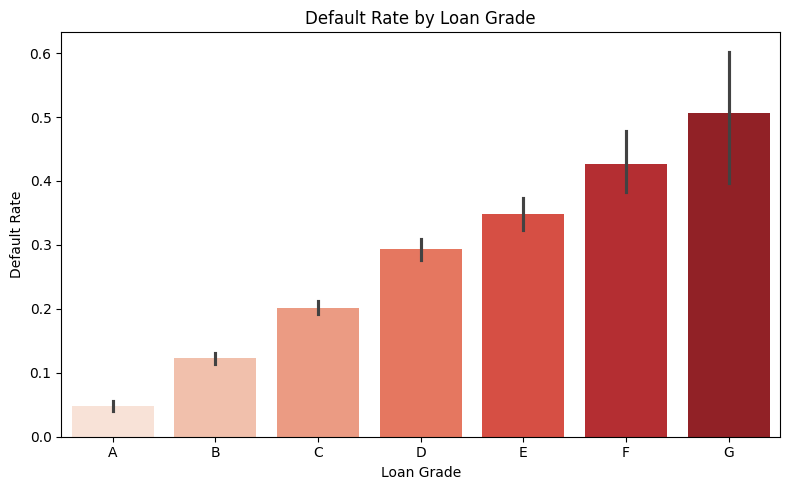

In [ ]:
plt.figure(figsize=(8,5))
df_plot = df_original[df_original['grade'].isin(['A','B','C','D','E','F','G'])]
sns.barplot(x='grade', y='default', data=df_plot,
            order=['A','B','C','D','E','F','G'], palette='Reds')
plt.title('Default Rate by Loan Grade')
plt.xlabel('Loan Grade')
plt.ylabel('Default Rate')
plt.tight_layout()
plt.show()

/tmp/ipykernel_790/3777836353.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='home_ownership', y='default', data=df_original, palette='Blues')


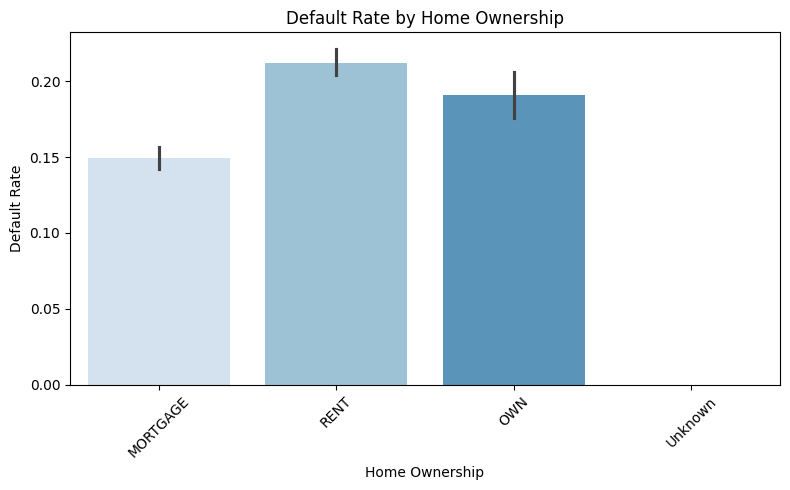

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(x='home_ownership', y='default', data=df_original, palette='Blues')
plt.title('Default Rate by Home Ownership')
plt.xlabel('Home Ownership')
plt.ylabel('Default Rate')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

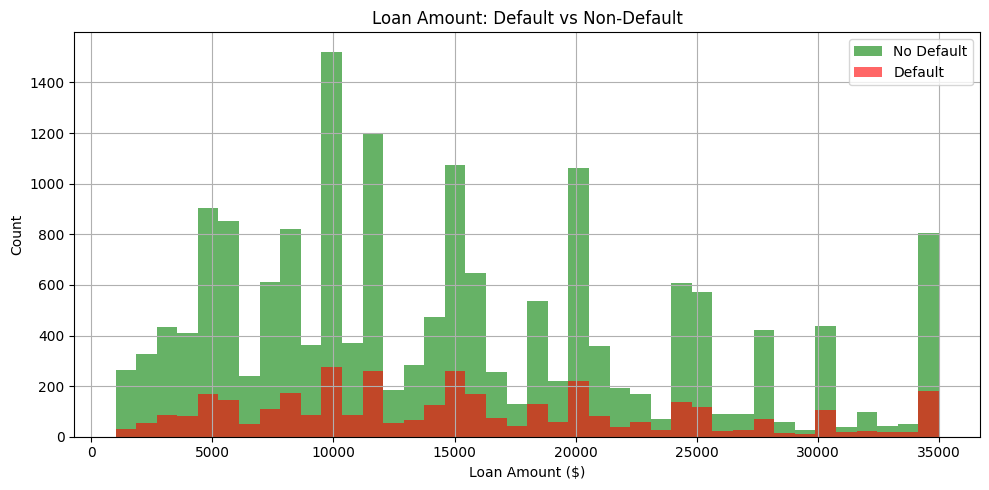

In [ ]:
plt.figure(figsize=(10,5))
df_original[df_original['default']==0]['loan_amnt'].hist(
    alpha=0.6, bins=40, label='No Default', color='green')
df_original[df_original['default']==1]['loan_amnt'].hist(
    alpha=0.6, bins=40, label='Default', color='red')
plt.title('Loan Amount: Default vs Non-Default')
plt.xlabel('Loan Amount ($)')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

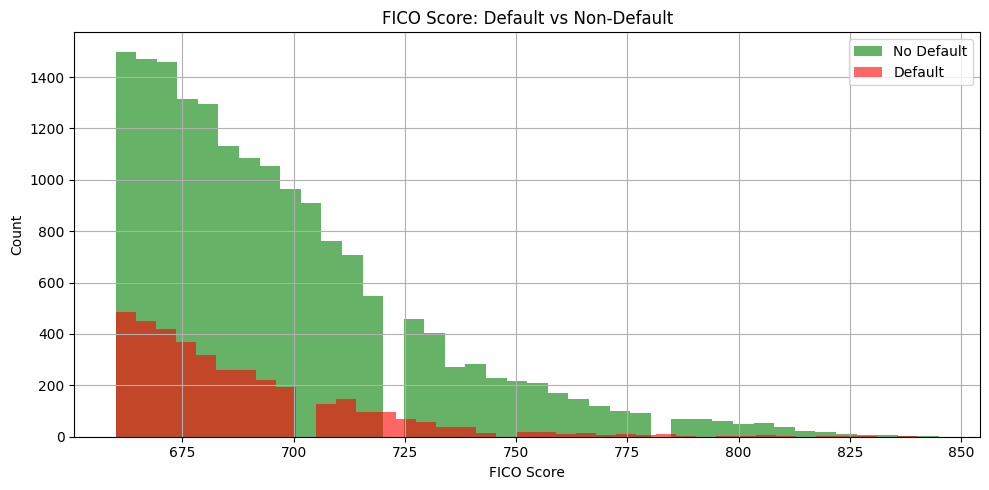

In [ ]:
fico_col = 'fico_range_low' if 'fico_range_low' in df.columns else 'fico_range_high'

plt.figure(figsize=(10,5))
df_original[df_original['default']==0][fico_col].hist(
    alpha=0.6, bins=40, label='No Default', color='green')
df_original[df_original['default']==1][fico_col].hist(
    alpha=0.6, bins=40, label='Default', color='red')
plt.title('FICO Score: Default vs Non-Default')
plt.xlabel('FICO Score')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

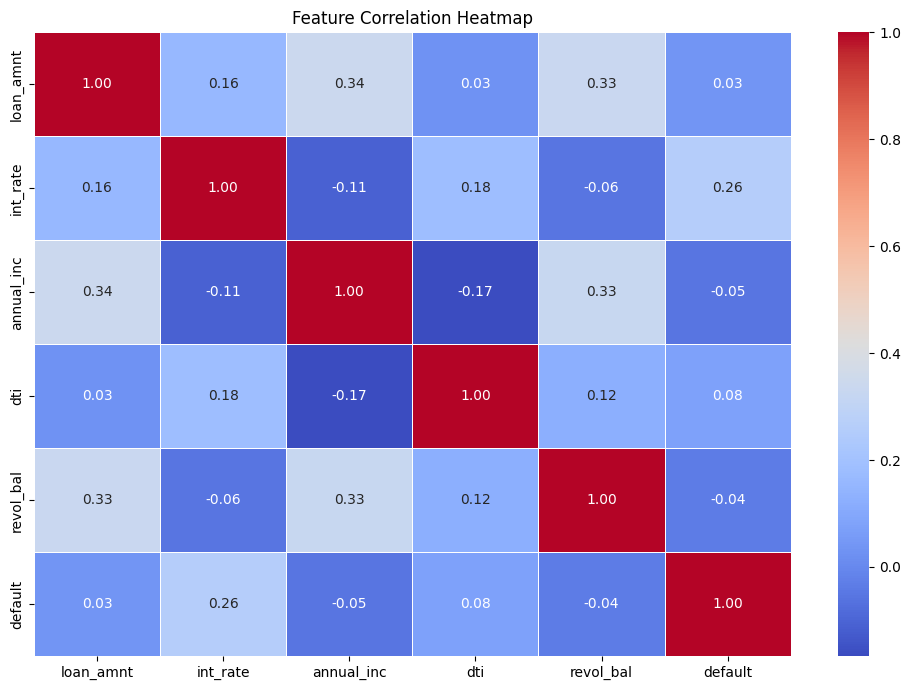

In [ ]:
num_cols = ['loan_amnt', 'int_rate', 'annual_inc', 'dti', 'revol_bal', 'default']
num_cols = [c for c in num_cols if c in df_original.columns]

plt.figure(figsize=(10,7))
sns.heatmap(df_original[num_cols].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

In [ ]:
cols_to_encode = [c for c in ['grade','home_ownership','purpose'] if c in df.columns]
df = pd.get_dummies(df, columns=cols_to_encode, drop_first=True)
print("Final shape after encoding:", df.shape)

Final shape after encoding: (21071, 157)


In [ ]:
df['dti_custom'] = df['installment'] / (df['annual_inc'] / 12)
print (df['dti_custom'])

0        0.026843
1        0.151436
2        0.082411
3        0.090535
4        0.033312
           ...   
21066    0.118601
21067    0.083271
21068    0.049223
21069    0.099712
21070    0.068061
Name: dti_custom, Length: 21071, dtype: float64


In [55]:
df['credit_util'] = df['revol_util'] / 100

In [43]:
df['loan_to_income'] = df['loan_amnt'] / (df['annual_inc'] + 1)
print(df['loan_to_income'])

0        0.065453
1        0.379994
2        0.317455
3        0.318179
4        0.099584
           ...   
21066    0.392813
21067    0.192312
21068    0.166665
21069    0.248060
21070    0.207833
Name: loan_to_income, Length: 21071, dtype: float64


In [56]:
df['has_derog'] = df['mths_since_last_major_derog'].apply(
    lambda x: 0 if pd.isnull(x) else 1
)


In [57]:
df['has_revol_delinq'] = df['mths_since_recent_revol_delinq'].apply(
    lambda x: 0 if pd.isnull(x) else 1
)

In [58]:
df['has_pub_rec'] = (df['pub_rec'] > 0).astype(int)

In [59]:
print(df[['loan_to_income', 'credit_util', 'has_derog',
          'has_revol_delinq', 'has_pub_rec']].describe())

       loan_to_income   credit_util  has_derog  has_revol_delinq   has_pub_rec
count    21071.000000  21071.000000    21071.0           21071.0  21071.000000
mean         1.167087      0.514699        1.0               1.0      0.180390
std        137.778944      0.241899        0.0               0.0      0.384521
min          0.000309      0.000000        1.0               1.0      0.000000
25%          0.124998      0.334000        1.0               1.0      0.000000
50%          0.202015      0.512000        1.0               1.0      0.000000
75%          0.299991      0.700000        1.0               1.0      0.000000
max      20000.000000      1.343000        1.0               1.0      1.000000


In [60]:
features = ['loan_amnt', 'int_rate', 'annual_inc', 'dti',
            'fico_range_low', 'credit_util', 'loan_to_income',
            'has_derog', 'has_revol_delinq', 'has_pub_rec',
            'revol_bal', 'open_acc']

features = [f for f in features if f in df.columns]
print("Using features:", features)

X = df[features]
y = df['default']

print("X shape:", X.shape)
print("y distribution:\n", y.value_counts())

Using features: ['loan_amnt', 'int_rate', 'annual_inc', 'dti', 'fico_range_low', 'credit_util', 'loan_to_income', 'has_derog', 'has_revol_delinq', 'has_pub_rec', 'revol_bal', 'open_acc']
X shape: (21071, 12)
y distribution:
 default
0    17300
1     3771
Name: count, dtype: int64


In [61]:
X = X.fillna(X.median())
print("Missing values in X:", X.isnull().sum().sum())

Missing values in X: 0


In [62]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (16856, 12)
Test size: (4215, 12)


In [63]:

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", y_train_bal.value_counts().to_dict())

Before SMOTE: {0: 13854, 1: 3002}
After SMOTE: {0: 13854, 1: 13854}


In [64]:
from sklearn.linear_model import LogisticRegression

print("Training Logistic Regression...")
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_bal, y_train_bal)
print("Done!")

Training Logistic Regression...
Done!


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [65]:
from sklearn.ensemble import RandomForestClassifier

print("Training Random Forest (takes 2-3 mins)...")
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_bal, y_train_bal)
print("Done!")

Training Random Forest (takes 2-3 mins)...
Done!


In [66]:
from xgboost import XGBClassifier

print("Training XGBoost...")
xgb = XGBClassifier(n_estimators=200, learning_rate=0.1,
                     max_depth=5, random_state=42,
                     eval_metric='logloss', n_jobs=-1)
xgb.fit(X_train_bal, y_train_bal)
print("Done!")

Training XGBoost...
Done!


In [67]:
from sklearn.metrics import roc_auc_score, classification_report
from scipy.stats import ks_2samp

print("="*50)
for name, model in [('Logistic Regression', lr),
                     ('Random Forest', rf),
                     ('XGBoost', xgb)]:
    probs = model.predict_proba(X_test)[:,1]
    auc = roc_auc_score(y_test, probs)

    pos_probs = probs[y_test == 1]
    neg_probs = probs[y_test == 0]
    ks = ks_2samp(pos_probs, neg_probs).statistic

    print(f"{name}")
    print(f"  AUC-ROC : {auc:.3f}")
    print(f"  KS Stat : {ks:.3f}")
    print("="*50)

Logistic Regression
  AUC-ROC : 0.687
  KS Stat : 0.290
Random Forest
  AUC-ROC : 0.682
  KS Stat : 0.286
XGBoost
  AUC-ROC : 0.680
  KS Stat : 0.266


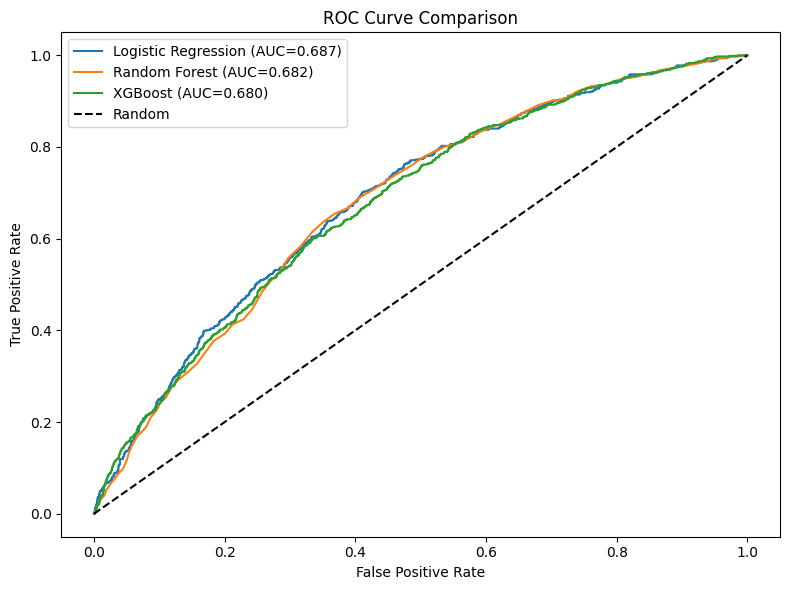

In [68]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(8,6))
for name, model in [('Logistic Regression', lr),
                     ('Random Forest', rf),
                     ('XGBoost', xgb)]:
    probs = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')

plt.plot([0,1],[0,1],'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.tight_layout()
plt.show()

In [69]:
import pickle

with open('xgb_model.pkl', 'wb') as f:
    pickle.dump(xgb, f)

with open('features.pkl', 'wb') as f:
    pickle.dump(features, f)

print("Model saved!")

Model saved!


In [70]:
import shap

print("Creating SHAP explainer (takes a minute)...")
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

with open('explainer.pkl', 'wb') as f:
    pickle.dump(explainer, f)

print("Done!")

Creating SHAP explainer (takes a minute)...
Done!


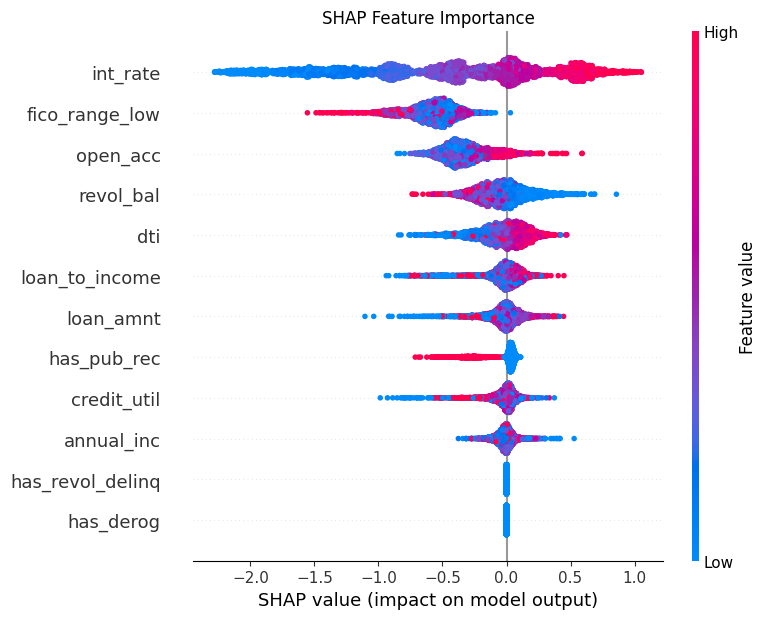

In [71]:
plt.figure()
shap.summary_plot(shap_values, X_test, plot_type="dot", show=False)
plt.title("SHAP Feature Importance")
plt.tight_layout()
plt.show()

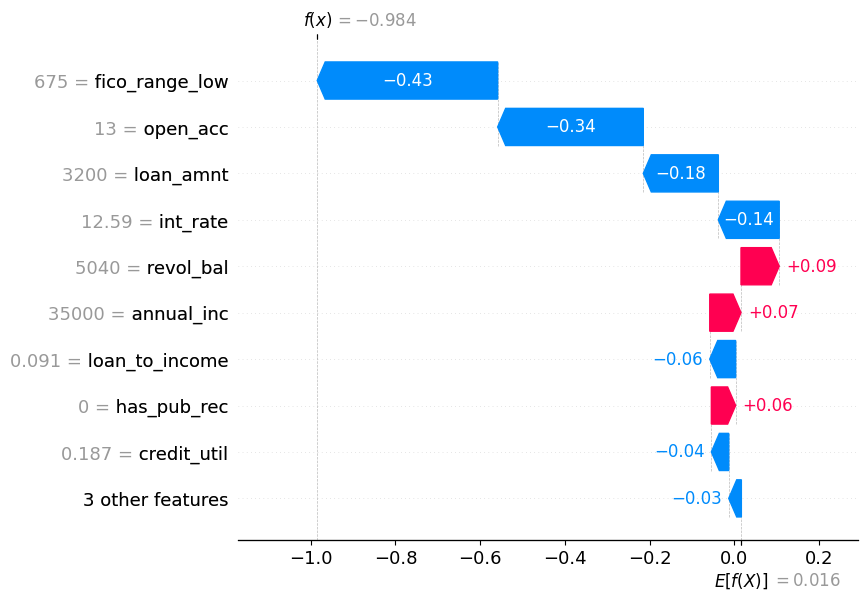

In [72]:
i = 0

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[i],
        base_values=explainer.expected_value,
        data=X_test.iloc[i].values,
        feature_names=features
    )
)

In [78]:
from google.colab import files

files.download('xgb_model.pkl')
files.download('features.pkl')
files.download('explainer.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [80]:
from google.colab import files
files.download('credit_scorecard.ipynb')

FileNotFoundError: Cannot find file: credit_scorecard.ipynb